In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from src.main import get_data


data = get_data(["AA"], "2009-01-01", "2026-06-01")

data.columns = data.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [3]:
def n_days_before(indices, date, n):
    index = indices.get_loc(date)
    index -= n
    index = max(min(index, len(indices)), 0)
    
    return indices[index]

def filter_cusum(close: pd.Series, h):
    filter_dates = []
    neg_cusum = 0
    pos_cusum = 0
    
    returns = close.diff()
    
    
    for date in returns.index[1:]:
        neg_cusum = min(0, neg_cusum + returns.loc[date])
        pos_cusum = max(0, pos_cusum + returns.loc[date])
        
        if neg_cusum < -h:
            filter_date =n_days_before(close.index, date, 10)
            
            filter_dates.append(filter_date)
            neg_cusum = 0
            
        elif pos_cusum > h:
            filter_date =n_days_before(close.index, date, 10)
            
            filter_dates.append(filter_date)
            pos_cusum = 0
            
            
    return pd.DatetimeIndex(filter_dates)

In [79]:
def create_row(start, end, num_day, label, ret, hit_day):
        return {"start":start, "end":end, "num_day": num_day, "label": label, "return": ret, "hit_day": hit_day}

def n_plus_date(close: pd.Series, date, n):
    loc = close.index.get_loc(date)
    result = close.iloc[loc : loc + n]
    
    return result

def create_labels(close: pd.Series, filter = None, top=0.1, bot=0.1, side=30):
    labeled_days = []
    
    side -= 1
    
    if filter is not None:
        dates = filter
    else:
        dates = close.iloc[:len(close)-side].index
    
    for date in dates:
        period = n_plus_date(close, date, side)
        
        num_day, label, ret, hit_day = label_period(period, top, bot)
        
        labeled_days.append(
            create_row(
                period.index[0], period.index[-1],
                num_day, label, ret, hit_day
            )
        )
        
    df = pd.DataFrame(labeled_days)
    df.index = df["start"]
    return df

def label_period(period: pd.Series, top=0.1, bot=0.1):
    initial_day = period.iloc[0]
    
    result = (period - initial_day) / initial_day
    
    for i, (day, val) in enumerate(result.items()):
        if val >= top:
            return (i, 1, val, day)
        if val <= -bot:
            return (i, -1, val, day)
    
    return (period.shape[0], 0, result.iloc[-1], period.index[-1])




In [9]:
def indice_matrix(indices, periods):
    matrix = pd.DataFrame(0, index=indices, columns=range(len(periods)))
    
    for i, (a,b) in enumerate(periods):
        matrix.loc[a:b,i] = 1
    return matrix

def get_avg_uniqueness(ind_matrix):
    c = ind_matrix.sum(axis=1)                 # concurrency per bar
    u = ind_matrix.div(c, axis=0)             # per-bar uniqueness
    avgU = u[u > 0].mean()             # average over active bars per event
    return avgU

0      0.270833
1      0.270833
2      0.270833
3      0.625000
4      1.000000
         ...   
695    0.162897
696    0.159524
697    0.174675
698    0.330519
699    0.188839
Length: 700, dtype: float64

In [ ]:
def seq_bootstrap(indM, sLength=None):
    M = indM.values.astype(float)          # bars x events
    cols = indM.columns
    n_events = M.shape[1]
    if sLength is None:
        sLength = n_events

    phi = []
    drawn_concurrency = np.zeros(M.shape[0])   # running concurrency from phi

    while len(phi) < sLength:
        # candidate concurrency = already-drawn + this candidate, per bar
        # c_i[t] = drawn_concurrency[t] + M[t, i]
        active = M > 0
        
        c = drawn_concurrency[:, None] + M       # bars x events
        u = np.divide(M, c, out=np.zeros_like(M), where=active)
        
        avgU = u.sum(axis=0) / active.sum(axis=0)   # mean over active bars
        prob = avgU / avgU.sum()

        j = np.random.choice(n_events, p=prob)
        phi.append(j)
        drawn_concurrency += M[:, j]                # update running concurrency

    return [cols[j] for j in phi]    # or just return phi for positional indices



In [11]:
# TODO: drawn duplicates weighting

In [40]:
df.index

DatetimeIndex(['2010-10-06', '2010-10-07', '2010-10-08', '2010-10-11',
               '2010-10-12', '2010-10-13', '2010-10-14', '2010-10-15',
               '2010-10-18', '2010-10-19',
               ...
               '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20',
               '2026-05-21', '2026-05-22', '2026-05-26', '2026-05-27',
               '2026-05-28', '2026-05-29'],
              dtype='datetime64[s]', name='Date', length=3935, freq=None)

In [14]:
def get_time_decay(avgU, clf_last_w=1.0):
    """
    avgU       : Series of average uniqueness per event (cumsum ordering = time)
    clf_last_w : weight of the OLDEST observation.
                 1   -> no decay
                 0   -> linear decay to 0 at oldest
                 <0  -> oldest fraction gets zero weight (dropped)
    """
    clfW = avgU.sort_index().cumsum()
    
    if clf_last_w >= 0:
        slope = (1.0 - clf_last_w) / clfW.iloc[-1]
    else:
        slope = 1.0 / ((clf_last_w + 1) * clfW.iloc[-1])
    const = 1.0 - slope * clfW.iloc[-1]
    clfW = const + slope * clfW
    clfW[clfW < 0] = 0                           # drop negatively-weighted
    return clfW.to_numpy()

In [15]:
def get_return_attribution(indM, t1, close):
    """
    close : pd.Series of prices (used for log returns)
    Weight_i = | sum_t ( r_t / c_t ) | over event i's active bars.
    Normalized to sum to number of events.
    """
    ret = np.log(close).diff().fillna(0)        # log returns per bar
    c = indM.sum(axis=1)                         # concurrency per bar
    w = pd.Series(index=t1[:, 0], dtype=float)
    
    for i, (t0, t1_) in enumerate(t1):
        # bars active for event i, attributed return = r_t / c_t
        attr = (ret.loc[t0:t1_] / c.loc[t0:t1_]).sum()
        w.iloc[i] = abs(attr)
    w *= w.shape[0] / w.sum()                    # normalize to sum = I
    return w.to_numpy()

## Features

In [17]:
mean = data["Close"].ewm(span=20, adjust=False).mean()
std = data["Close"].ewm(span=20, adjust=False).std(bias=False)

z = (data["Close"] - mean) / std
z = z.replace([np.inf, -np.inf], np.nan)


z

Date
2009-01-02         NaN
2009-01-05   -1.279527
2009-01-06    0.242882
2009-01-07   -1.982876
2009-01-08   -1.043786
                ...   
2026-05-22    1.831880
2026-05-26    2.001403
2026-05-27    1.395073
2026-05-28    1.575500
2026-05-29    1.603241
Name: Close, Length: 4378, dtype: float64

In [185]:

from src.features.frac_diff import differencing, find_d
from sklearn.preprocessing import StandardScaler

tau=1e-4

results, fd = find_d(data["Close"], range_list=[0.2, 0.5], alpha=0.05, max_depth=18)
ret = data["Close"].pct_change()

df = pd.DataFrame({
    "frac_diff_real":fd,
    "frac_diff": ret,
    "frac_diff_lag_2": ret.shift(2),
    "frac_diff_lag_3": ret.shift(3),
    "frac_diff_lag_4": ret.shift(4),
    "frac_diff_lag_5": ret.shift(5),
    "momentum_5": data["Close"] / data["Close"].shift(5) - 1,
    "z_score": z
        }, index=data.index)

df.dropna(inplace=True)


In [117]:
labels

,start,end,num_day,label,return,hit_day
start,,,,,,
2010-10-06,2010-10-06,2010-10-22,13,0,0.028294,2010-10-22
2010-10-21,2010-10-21,2010-11-08,13,0,0.094812,2010-11-08
2010-11-02,2010-11-02,2010-11-18,13,0,0.012869,2010-11-18
2010-11-17,2010-11-17,2010-12-06,12,1,0.100464,2010-12-06
2010-12-08,2010-12-08,2010-12-27,13,0,0.077086,2010-12-27
...,...,...,...,...,...,...
2026-05-07,2026-05-07,2026-05-26,11,1,0.141351,2026-05-22
2026-05-08,2026-05-08,2026-05-27,10,1,0.131596,2026-05-22
2026-05-11,2026-05-11,2026-05-28,10,1,0.143087,2026-05-26


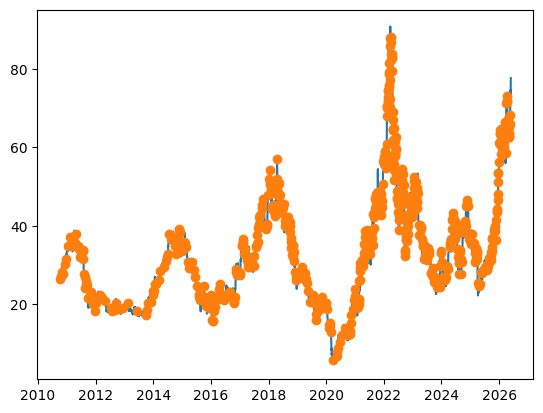

(639, 6)


In [142]:
label_data = data.loc[df.index[0]:]

top_events_filter = filter_cusum(label_data["Close"], 2)

dots = label_data["Close"][top_events_filter]

plt.plot(label_data["Close"])
plt.plot(dots, 'o')
plt.show()


labels = create_labels(label_data["Close"], filter=top_events_filter, side=14)
print(labels.shape)



ind_matrix = indice_matrix(label_data["Close"].index, labels[["start", "hit_day"]].values)
ind_matrix = ind_matrix.iloc[:, :len(labels.loc[:"2025"])]

avg_unique = get_avg_uniqueness(ind_matrix)


drawn = seq_bootstrap(ind_matrix, 300)

In [143]:
labels.iloc[drawn]

,start,end,num_day,label,return,hit_day
start,,,,,,
2015-07-06,2015-07-06,2015-07-22,13,0,-0.094288,2015-07-22
2017-06-01,2017-06-01,2017-06-19,13,0,-0.062234,2017-06-19
2022-08-05,2022-08-05,2022-08-23,13,0,0.074261,2022-08-23
2021-02-24,2021-02-24,2021-03-12,5,1,0.133456,2021-03-03
2011-11-09,2011-11-09,2011-11-28,10,-1,-0.129412,2011-11-23
...,...,...,...,...,...,...
2025-04-09,2025-04-09,2025-04-28,13,0,-0.011601,2025-04-28
2021-11-15,2021-11-15,2021-12-02,11,-1,-0.135295,2021-12-01
2020-05-12,2020-05-12,2020-05-29,6,1,0.145405,2020-05-20


In [191]:
train_raw = df.loc[labels.iloc[drawn]["start"]]
test_raw = df.loc[labels.loc["2026":].index]


scaler = StandardScaler()
X_train = train_raw
X_test = test_raw

y_train = np.array(labels.iloc[drawn]["label"])
y_test = np.array(labels.loc[test_raw.index]["label"])


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train) 
y_test_enc = le.transform(y_test)

In [ ]:
t_decay_w = get_time_decay(avg_unique, 0.4)
r_attr_w = get_return_attribution(ind_matrix, labels.loc[:"2025"][["start", "hit_day"]].values, data["Close"])

weights = (t_decay_w * r_attr_w)

In [192]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train_enc, sample_weight=weights[drawn])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [188]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test_enc, y_pred))

Accuracy: 0.325


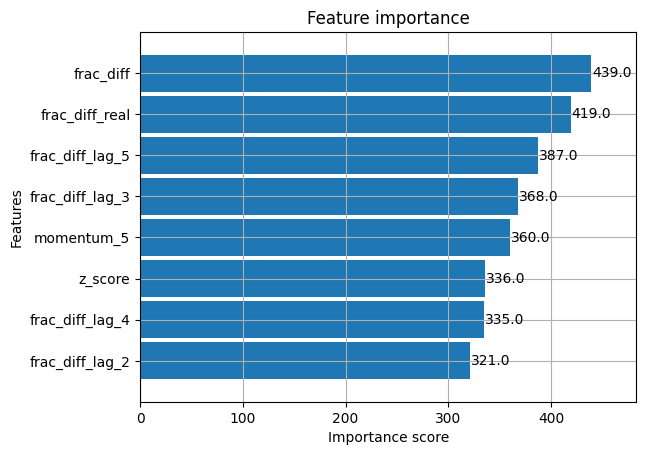

In [193]:
from xgboost import plot_importance


_ = plot_importance(model, height=0.9, max_num_features=12)